# Generative AI in Python and through web applications

## Session Overview

In this recitation, we will learn how to use Generative AI in Python and through web applications. Our learning objectives are:
1. Learn three approaches we can take to apply generative AI models and the differences between the methods
2. Be able to generate images from text through these approaches (called text-to-image)
3. Be able to generate text from images through these approaches (called image-to-text)
4. Be able to perform pure text-based tasks with these approaches (called text-to-text)

## Part 1: Three approaches for using generative AI models and their differences

### Three possible approaches

We will first learn three possible approaches we can take to apply generative AI models to the problems we want to tackle. <br><br>

**1.  🖥️ Local models**

The first approach is "local models". Local generative AI models are models that run entirely on a user's own machine without requiring internet access or API calls to external servers. These models are typically downloaded from platforms like [Hugging Face](https://huggingface.co/) and loaded using libraries such as [transformers](https://huggingface.co/docs/transformers/en/index). <br><br>

**2. 🔌 API-based models**

API-based generative AI models are accessed programmatically over the internet through an Application Programming Interface (API). These models run on remote servers (usually in the cloud) and can generate text, images, audio, or code in response to input sent via structured requests. Users don’t need to download the model or manage infrastructure — just authenticate with an API key and send queries. This approach allows seamless integration into apps, services, and workflows. Examples include OpenAI's GPT via the OpenAI API, Anthropic’s Claude API, and Stability AI’s image generation APIs.<br><br>

**3. 🌐 Web-Based Models**
Web-based generative AI models are accessed through a browser interface and require no coding or installation. These platforms let users interact with powerful models in real time by entering prompts or uploading files. The underlying model still runs on cloud infrastructure, but the interaction is simplified for general users. Tools like ChatGPT (OpenAI), Meta AI’s web assistant, Claude.ai, and Gemini (by Google) fall into this category. They're ideal for casual use, prototyping, and accessibility, often wrapped in user-friendly features like memory, file upload, or chat history.<br><br>

### Their differences
Let's learn more about why you may want to use one approach over the others -- in other words, their differences.
## ⚖️ Comparison of Local, API-Based, and Web-Based Models by Need / Usage

| **Need / Use Case**                                 | **Local Models**                                               | **API-Based Models**                                                      | **Web-Based Models**                                                |
|-----------------------------------------------------|----------------------------------------------------------------|---------------------------------------------------------------------------|----------------------------------------------------------------------|
| **No internet access / full offline use**           | ✅ Yes — fully offline once downloaded                         | ❌ No — requires internet                                                 | ❌ No — browser-based and always online                              |
| **Storage space**              | ❌ May require sizeable amount of storage                   | ✅ No storage required                               | ✅ No storage required   
| **High performance or scalability**                 | ❌ Limited by local hardware                                   | ✅ Scales easily with cloud infrastructure                                | ❌ Limited to the platform’s UI and session limits                   |
| **Data privacy / sensitive information**            | ✅ Best — data stays on your machine                           | ⚠️ Varies by provider — check policies                                   | ❌ Data may be logged or used to improve the model                   |
| **Ease of setup / no coding required**              | ❌ Requires coding and technical setup                   | ⚠️ Easy for developers, but coding required                               | ✅ Easiest — just open in a browser                                  |
| **Integration into custom apps or workflows**       | ✅ Flexible — full control                                     | ✅ Easy integration into apps                          | ❌ Limited — typically cannot integrate directly                     |
| **No cost after setup**                             | ✅ Yes — free after download (especially with open models)     | ⚠️ Sometimes free, sometimes not                                      | ⚠️ Free tier may have limits; paid for advanced access              |
| **Access to latest models / updates automatically** | ❌ Manual updates required                                     | ⚠️ Latest version, not necessarily latest model                                 | ✅ Yes — providers update models behind the scenes                   |
| **Best for beginners / casual users**               | ⚠️ May not be beginner-friendly                                        | ⚠️ May not be beginner-friendly                                                    | ✅ Yes — intuitive interface                                         |
| **Best for research / fine-tuning / experimentation** | ✅ Great — full model access                                   | ⚠️ Limited depending on provider/model access                            | ❌ Usually not supported                                             |

<!--
**1. 🖥️ Local Models**  

| ✅ Pros                                                         | ❌ Cons                                                                          |
|----------------------------------------------------------------|----------------------------------------------------------------------------------|
| Full data privacy — no data leaves your machine                | Requires sufficient hardware (RAM, VRAM, disk)                                  |
| No internet or API key needed once downloaded                  | Setup and dependencies can be complex                                           |
| No usage limits — cost depends only on local resources         | Updates and new features must be managed manually                               |
| Greater flexibility for customization and offline use          | Performance may be slower on consumer hardware, especially for large models     |

<br>

**2. 🔌 API-Based Models**

| ✅ Pros                                                         | ❌ Cons                                                                          |
|----------------------------------------------------------------|----------------------------------------------------------------------------------|
| Easy to integrate into apps or pipelines with minimal setup    | Requires internet connection                                                    |
| Scales well — no need for high-end local hardware              | Usage-based pricing can become expensive                                        |
| Always up-to-date with the latest model versions               | Data privacy depends on the provider’s handling policies                        |
| Ideal for production services and automation                   | Rate limits or quotas may apply                                                 |

<br>

**3. 🌐 Web-Based Models**

| ✅ Pros                                                         | ❌ Cons                                                                          |
|----------------------------------------------------------------|----------------------------------------------------------------------------------|
| Most user-friendly — no coding or setup required               | Limited flexibility or customization                                            |
| Quick access to powerful models                                | Usually not open-source or transparent about model internals                    |
| Great for casual use, testing, or brainstorming                | Data input may be stored or used for model improvement                          |
| Often free (with usage caps) or tiered pricing for more features | Not suited for large-scale or automated workflows                              | -->

# Part 2: Text-to-image

Let's now dive into generating images from text using each of the three methods.
We will first use a local stable diffusion model. Recall that you have learned about stable diffusion models in this module's lectures.

As usual, we need to first install any required libraries into this environment.

In [ ]:
# Install required libraries
!pip install --quiet diffusers transformers accelerate scipy safetensors

We now import the required libraries.

In [2]:
# Import necessary packages
from diffusers import StableDiffusionPipeline
import torch
from PIL import Image
import matplotlib.pyplot as plt

Now, we locally load the pretrained stable diffusion model from HuggingFace (more information [here](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5)). This means that the model itself is now loaded locally onto this notebook's GPU (not via an API!). The first time you run the code below, it will download the mdoel from the Hugging Face Hub (~4GB). The ID of our model is `table-diffusion-v1-5/stable-diffusion-v1-5`, and we load it from HuggingFace using this ID and the `StableDiffusionPipeline`, which is a . We also specify a few other parameters:
- `torch_dtype=torch.float16` tells the model to use half-precision (`float16`) instead of full-precision (`float32`). We use this because `float16` uses half the memory and speeds up inference, which is important on Colab's limited GPUs. Note that this requires a GPU that supports `float16` operations (which Colab usually provides).
- `use_safetensors=True` enables loading the model from .safetensors files instead of .bin files. We use this bceause `.safetensors` format is faster, safer, and non-executable (mitigates security risks). It’s also more compatible with `float16` pipelines and Hugging Face’s optimized loading.

Though we have loaded the `runwayml` model here, you can also load other text-to-image models by changing the `model_id` variable. Some examples include:
- `runwayml/stable-diffusion-v1-5`: clasic stable diffusion, great general-purpose text-to-image (what we have used in this recitation)
- `stabilityai/stable-diffusion-2-1`: gives higher resolution, allows more refined prompts
- `nitrosocke/mo-di-diffusion`: specialized in 3D models/cinematic-style images

In [ ]:
# Load model from Hugging Face (runs locally in Colab with GPU support)
model_id = "runwayml/stable-diffusion-v1-5"

stablediff_pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    use_safetensors=True
).to("cuda")  # Use GPU

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

We now give our stable diffusion model a prompt, and, using the `pipe` object from above, we ask the model to generate an image from the prompt. Using the `plt` library, we display the image we just generated! Note that the `plt.axis("off")` code simply removes any axes from the display.

Isn't out image cool? Feel free to play around with these models more to generate more images from text.

  0%|          | 0/50 [00:00<?, ?it/s]

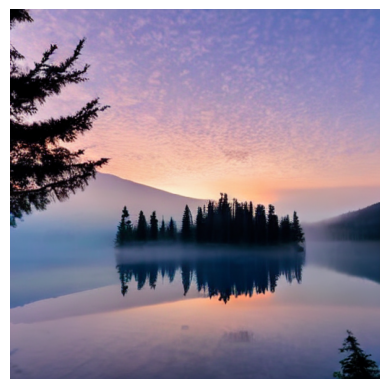

In [6]:
# Generate an image from text
prompt = "A serene mountain lake at sunrise, with mist and pine trees"
image = stablediff_pipe(prompt).images[0]

# Display the generated image
plt.imshow(image)
plt.axis("off")
plt.show()

Next, we will use the second approach for the text-to-image task, and we will use one of the diffusion models from [StabilityAI](https://stability.ai/). We need to first install the Python client that will allow us to interact with StabilityAI's API service and import all relevant packages.

In [1]:
# Install the StabilityAI Python client
!pip install --quiet stability-sdk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 66.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires grpcio>=1.71.2, but you have grpcio 1.63.2 which is incompatible.


In [2]:
# Import required packages
import os
from getpass import getpass
from stability_sdk import client
from stability_sdk.interfaces.gooseai.generation import generation_pb2 as gen
from IPython.display import display
from PIL import Image
import io

The below code sets the API key for the StabilityAI API service. The `getpass` function allows me to input the API key while keeping it private/invisible to public view.

In [3]:
# Set your StabilityAI API key
api_key = getpass("Enter your Stability AI (DreamStudio) API key: ")
os.environ["STABILITY_KEY"] = api_key

Enter your Stability AI (DreamStudio) API key: ··········


Note that if you would like to run this code on your own, you will need to generate your own API key, since it is unique for each person. You can do this by following these steps:
1. Create a free account at StabilityAI's [website](https://platform.stability.ai/)
2. Go to your Account page (by clicking on the upper right-hand side's person icon). 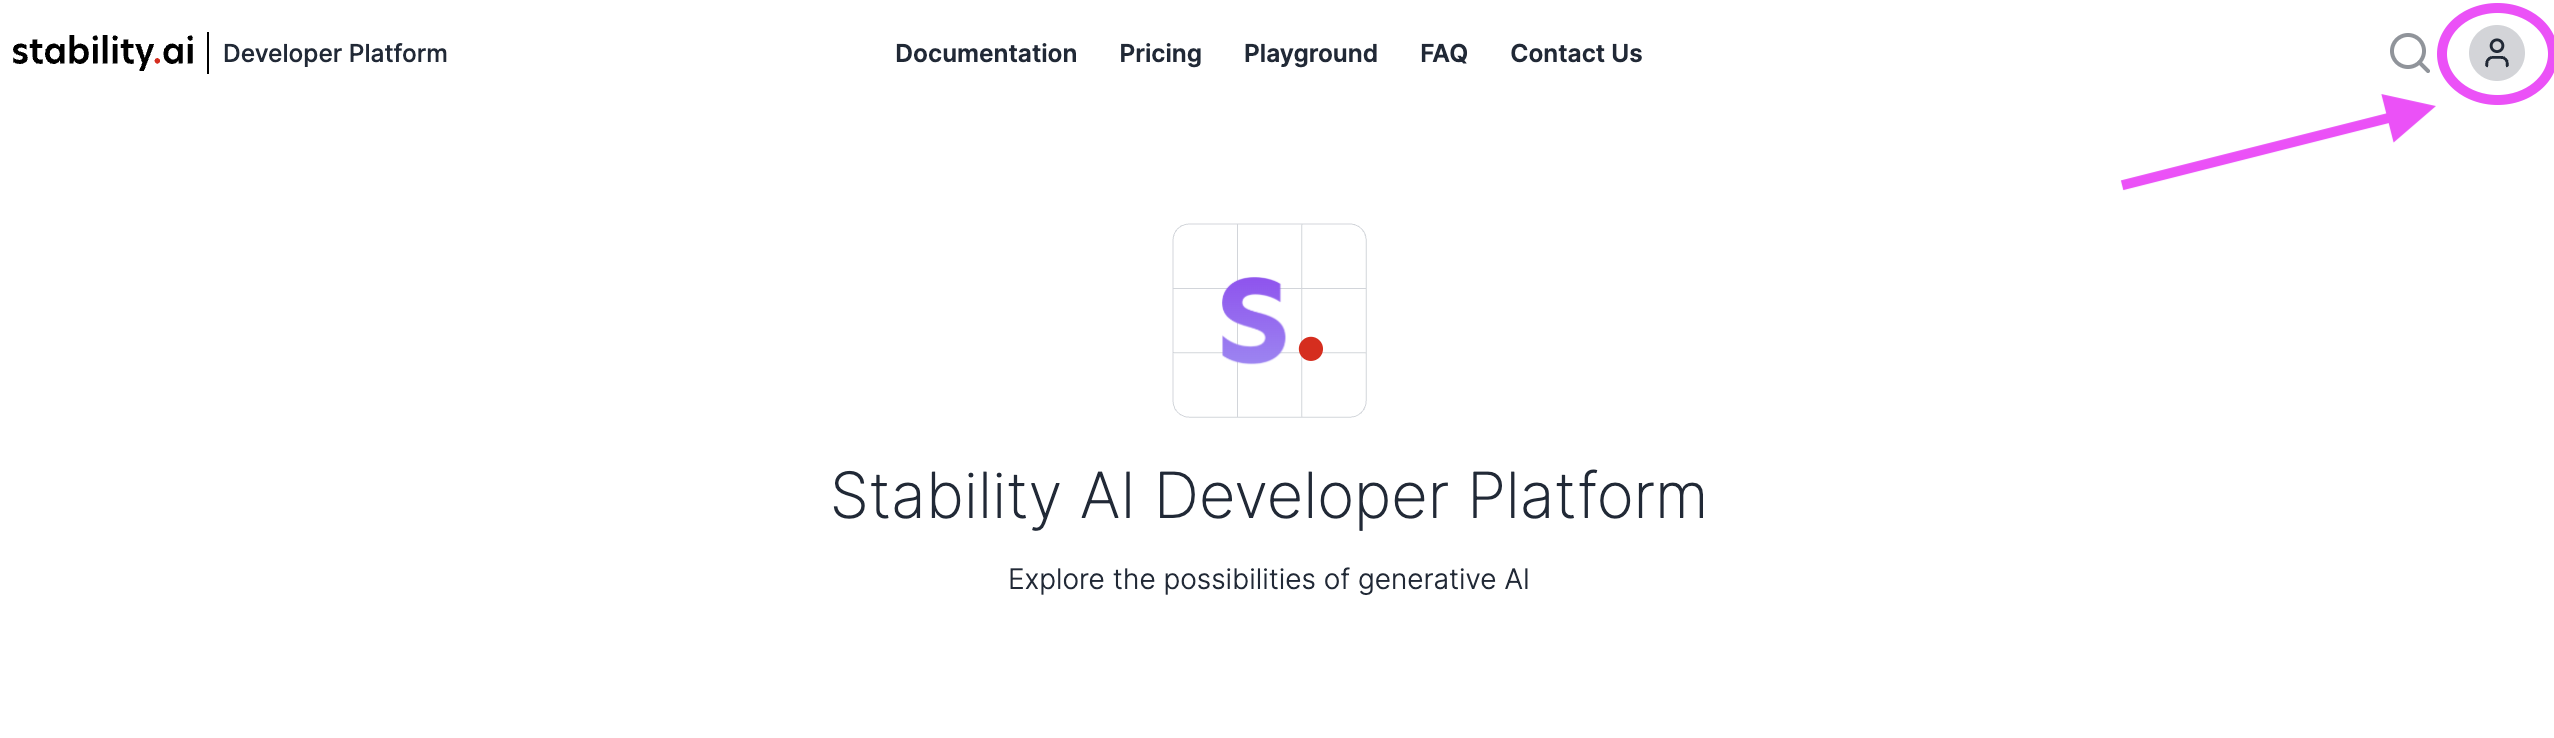
3. Click on API keys and click on the Create API Key button, and you can use the two squares icon to copy the key into your laptop's clipboard; you can then paste the key into this notebook! 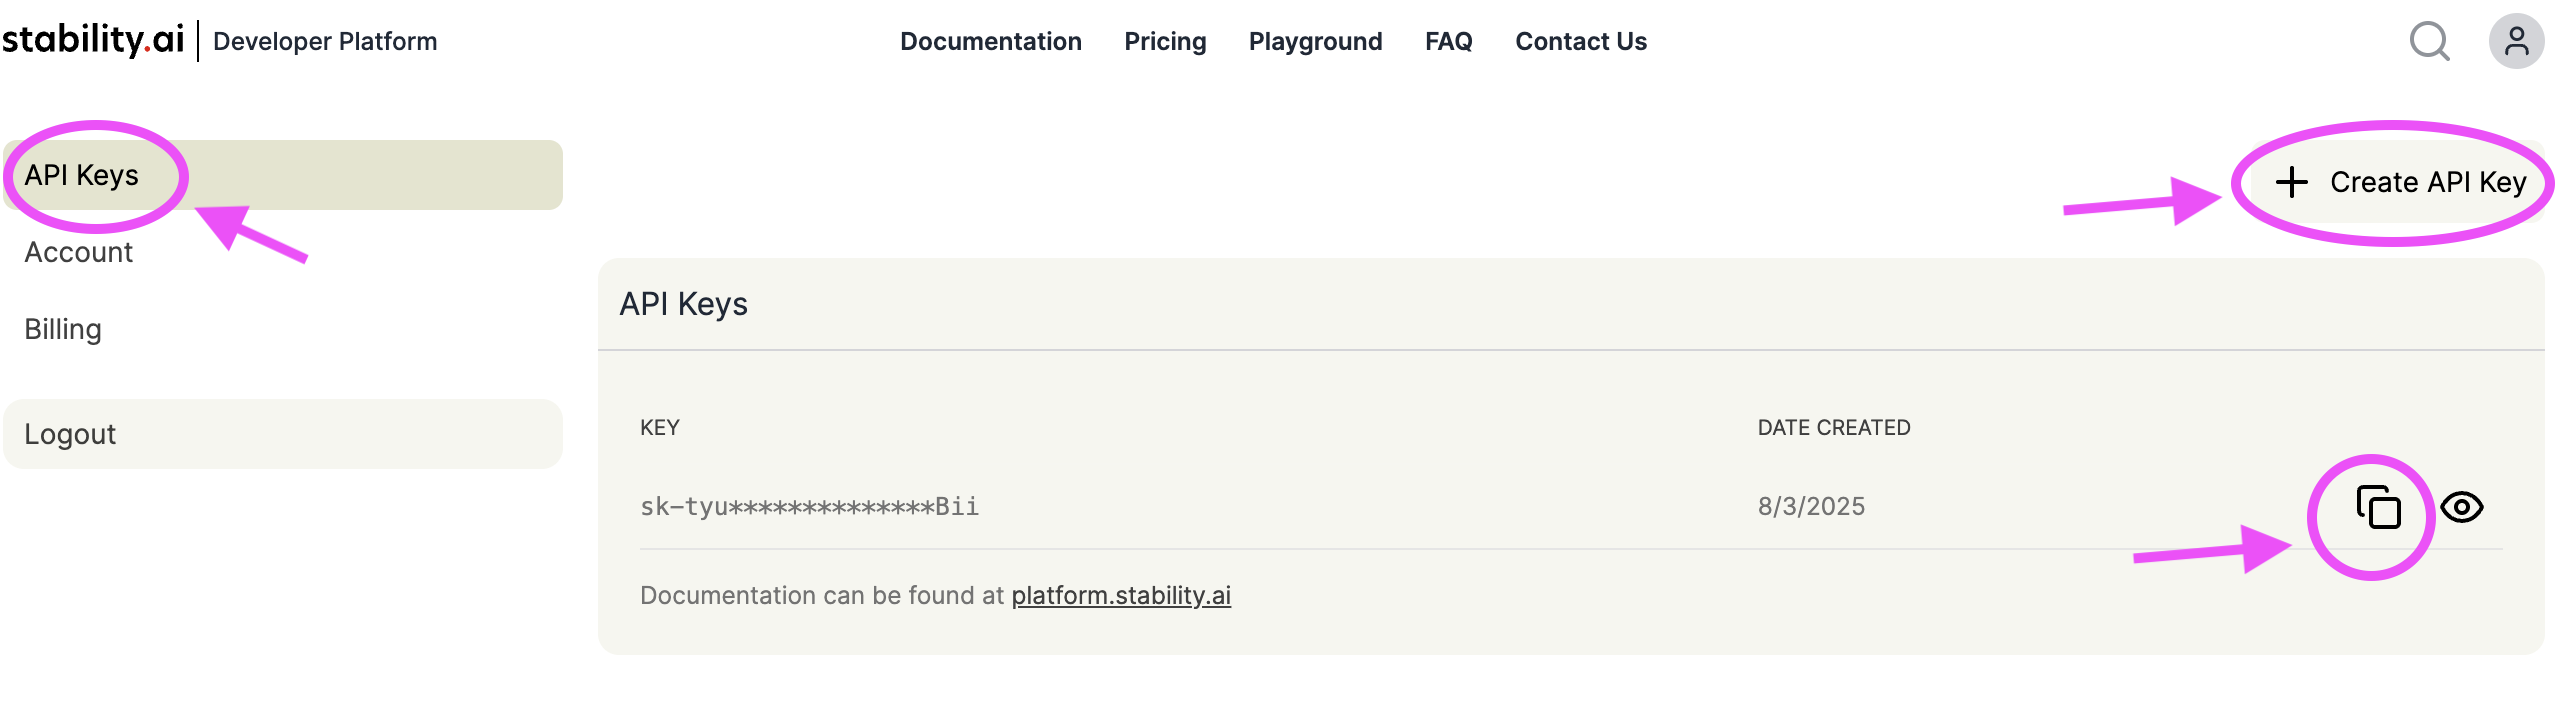

The following code will actually generate the image.

The first block creates and configures the API client, which is a piece of software (usually a library or object in your code) that lets you easily interact with an API by handling the communication for you. We set the following parameters for our API client:
- `key` is the Stability AI API key (string). It is usually set via os.getenv("STABILITY_KEY") for security.
- `engine` is the name of the model engine to use (e.g. `stable-diffusion-xl-1024-v1-0`). This is the name of the specific diffusion model from StabilityAI that we are using and helps determine image quality, size, and model architecture.

The second block of code prepares the details of the request, which we specify via the  following API client's parameters in the `generate` function:
- `prompt` is the  text description of the image you want to generate. Note that it must be a string (e.g., "a snowy mountain under the stars").
- `steps` is the number of diffusion steps (e.g., 20–50). Note that higher values produce more detailed and refined images, but take longer.
- `cfg_scale` is the Classifier-Free Guidance scale, which controls how closely the image matches the prompt. Note that lower values = more creative/divergent; higher = more literal. A common range is 6.0 – 9.0.
- `width` is the width of the output image (in pixels). Note that it must match supported sizes of the engine (e.g., 512, 1024).
- `height` is the height of the output image (in pixels). Note that it must match supported sizes of the engine.
- `samples` is the number of images to generate for this prompt in one call. This is typically set to 1–4.
The `answers` variable stores the generated image response from the API client.

The third block of code actually displays the generated image. More specifically, it loops through the API responses (since there may be moer than one response), finds the image data in the response, and converts it into a displayable image object.


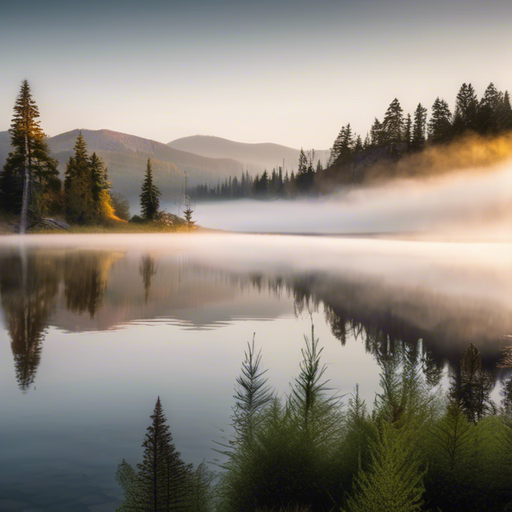

In [5]:
# Create and configure the API client
stability_api = client.StabilityInference(
    key=os.getenv("STABILITY_KEY"),
    engine="stable-diffusion-xl-1024-v1-0"  # or choose later models like "stable-diffusion-2-1" or "sdxl"
)

# Prepare request parameters
answers = stability_api.generate(
    prompt="A serene mountain lake at sunrise, with mist and pine trees",
    steps=30,
    cfg_scale=7.0,
    width=512,
    height=512,
    samples=1,
)

# Display the generated image
# Loop through API response
for resp in answers:
    # Look through each actual output (e.g. "artifact") from the API
    for artifact in resp.artifacts:
        # Determine if the artifact is an image
        if artifact.type == gen.ARTIFACT_IMAGE:
            # Convert the raw image data from bytes into a file-like object,
            # then read as actual image
            img = Image.open(io.BytesIO(artifact.binary))
            # Display the image in the notebook
            display(img)

Our image looks different from the local model, huh?

Last but not least for this text-to-image section, we will explore how to use web-based models to generate images. In particular, we will see how we can interact with ChatGPT.

We can ask ChatGPT directly to generate an image using a specific prompt, and it will return back an image. Let's see how it looks if we use the same mountain-related prompt as previously:
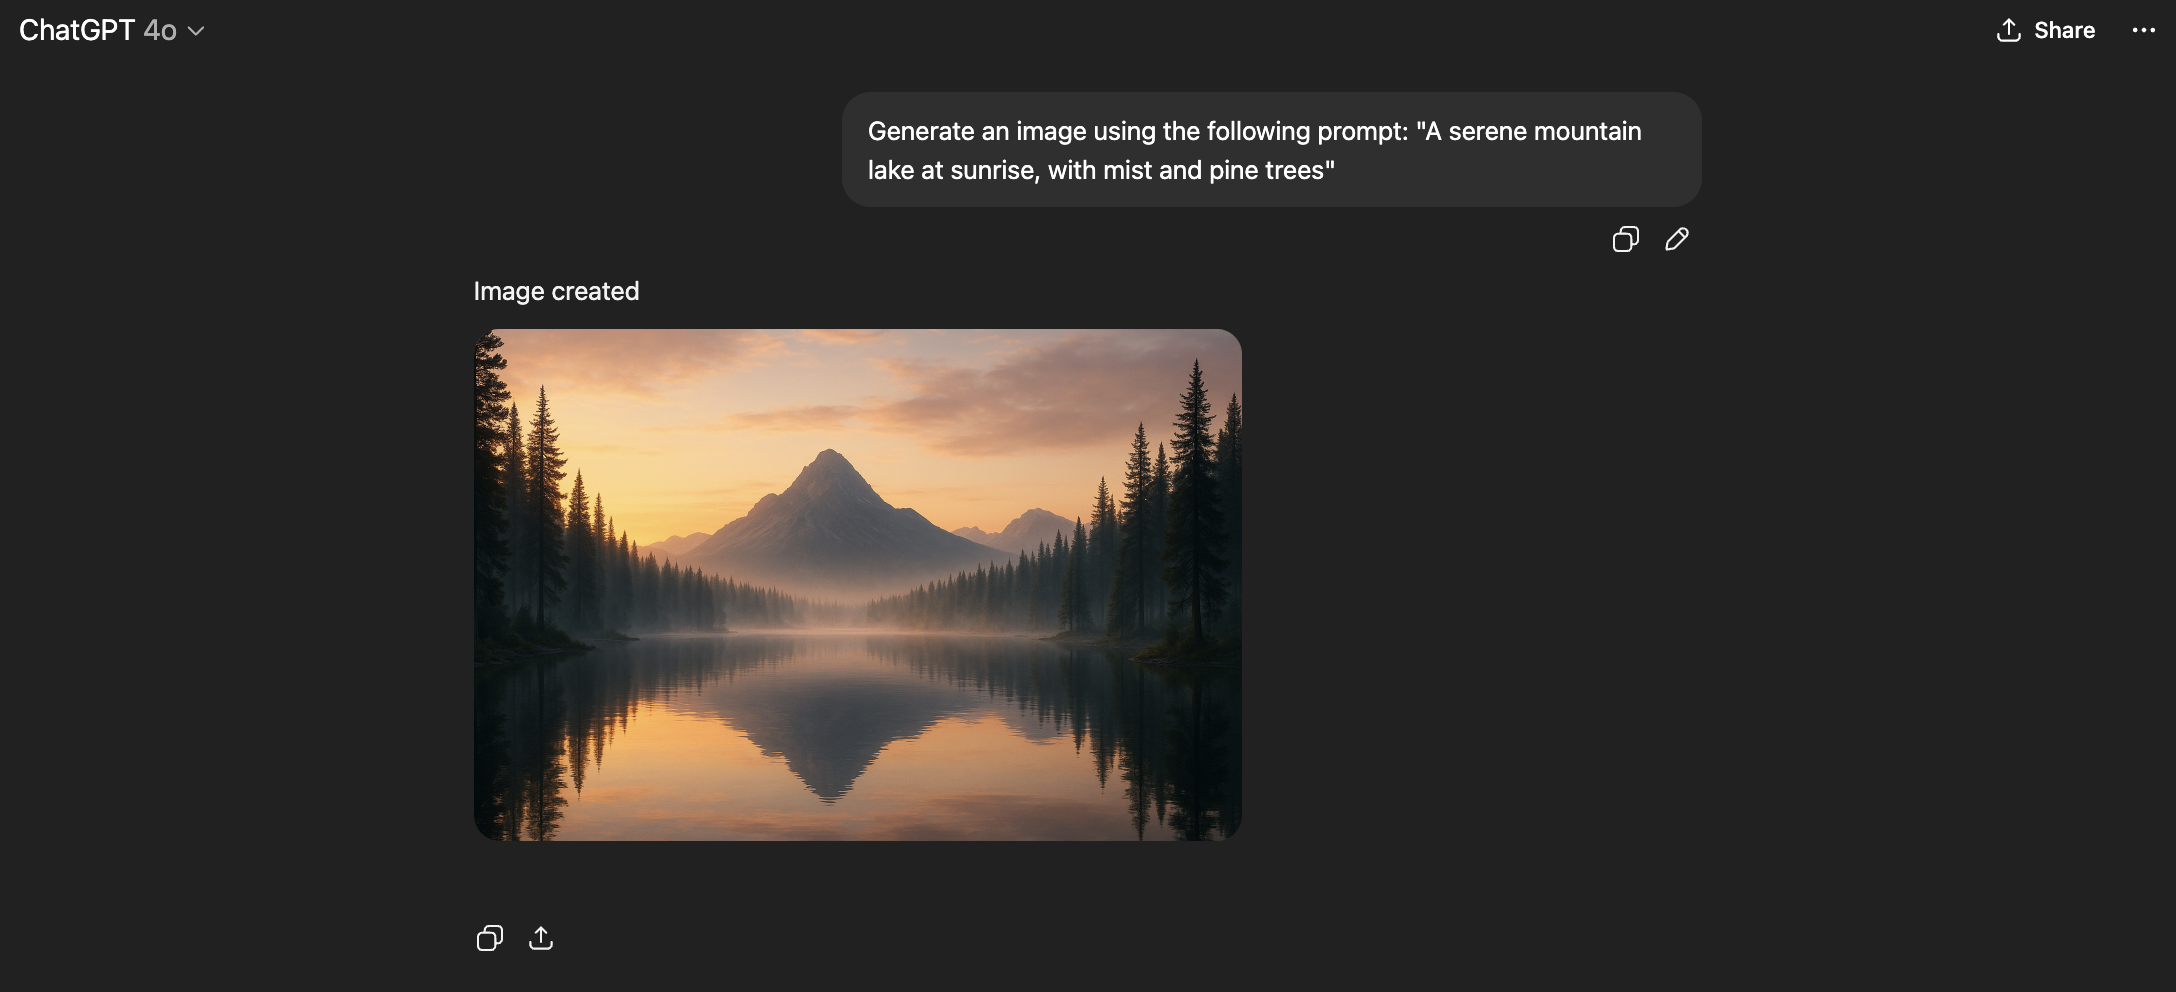

If you're curious, you can also ask ChatGPT what model generated the image and also other text-to-image models taht you may want to use:
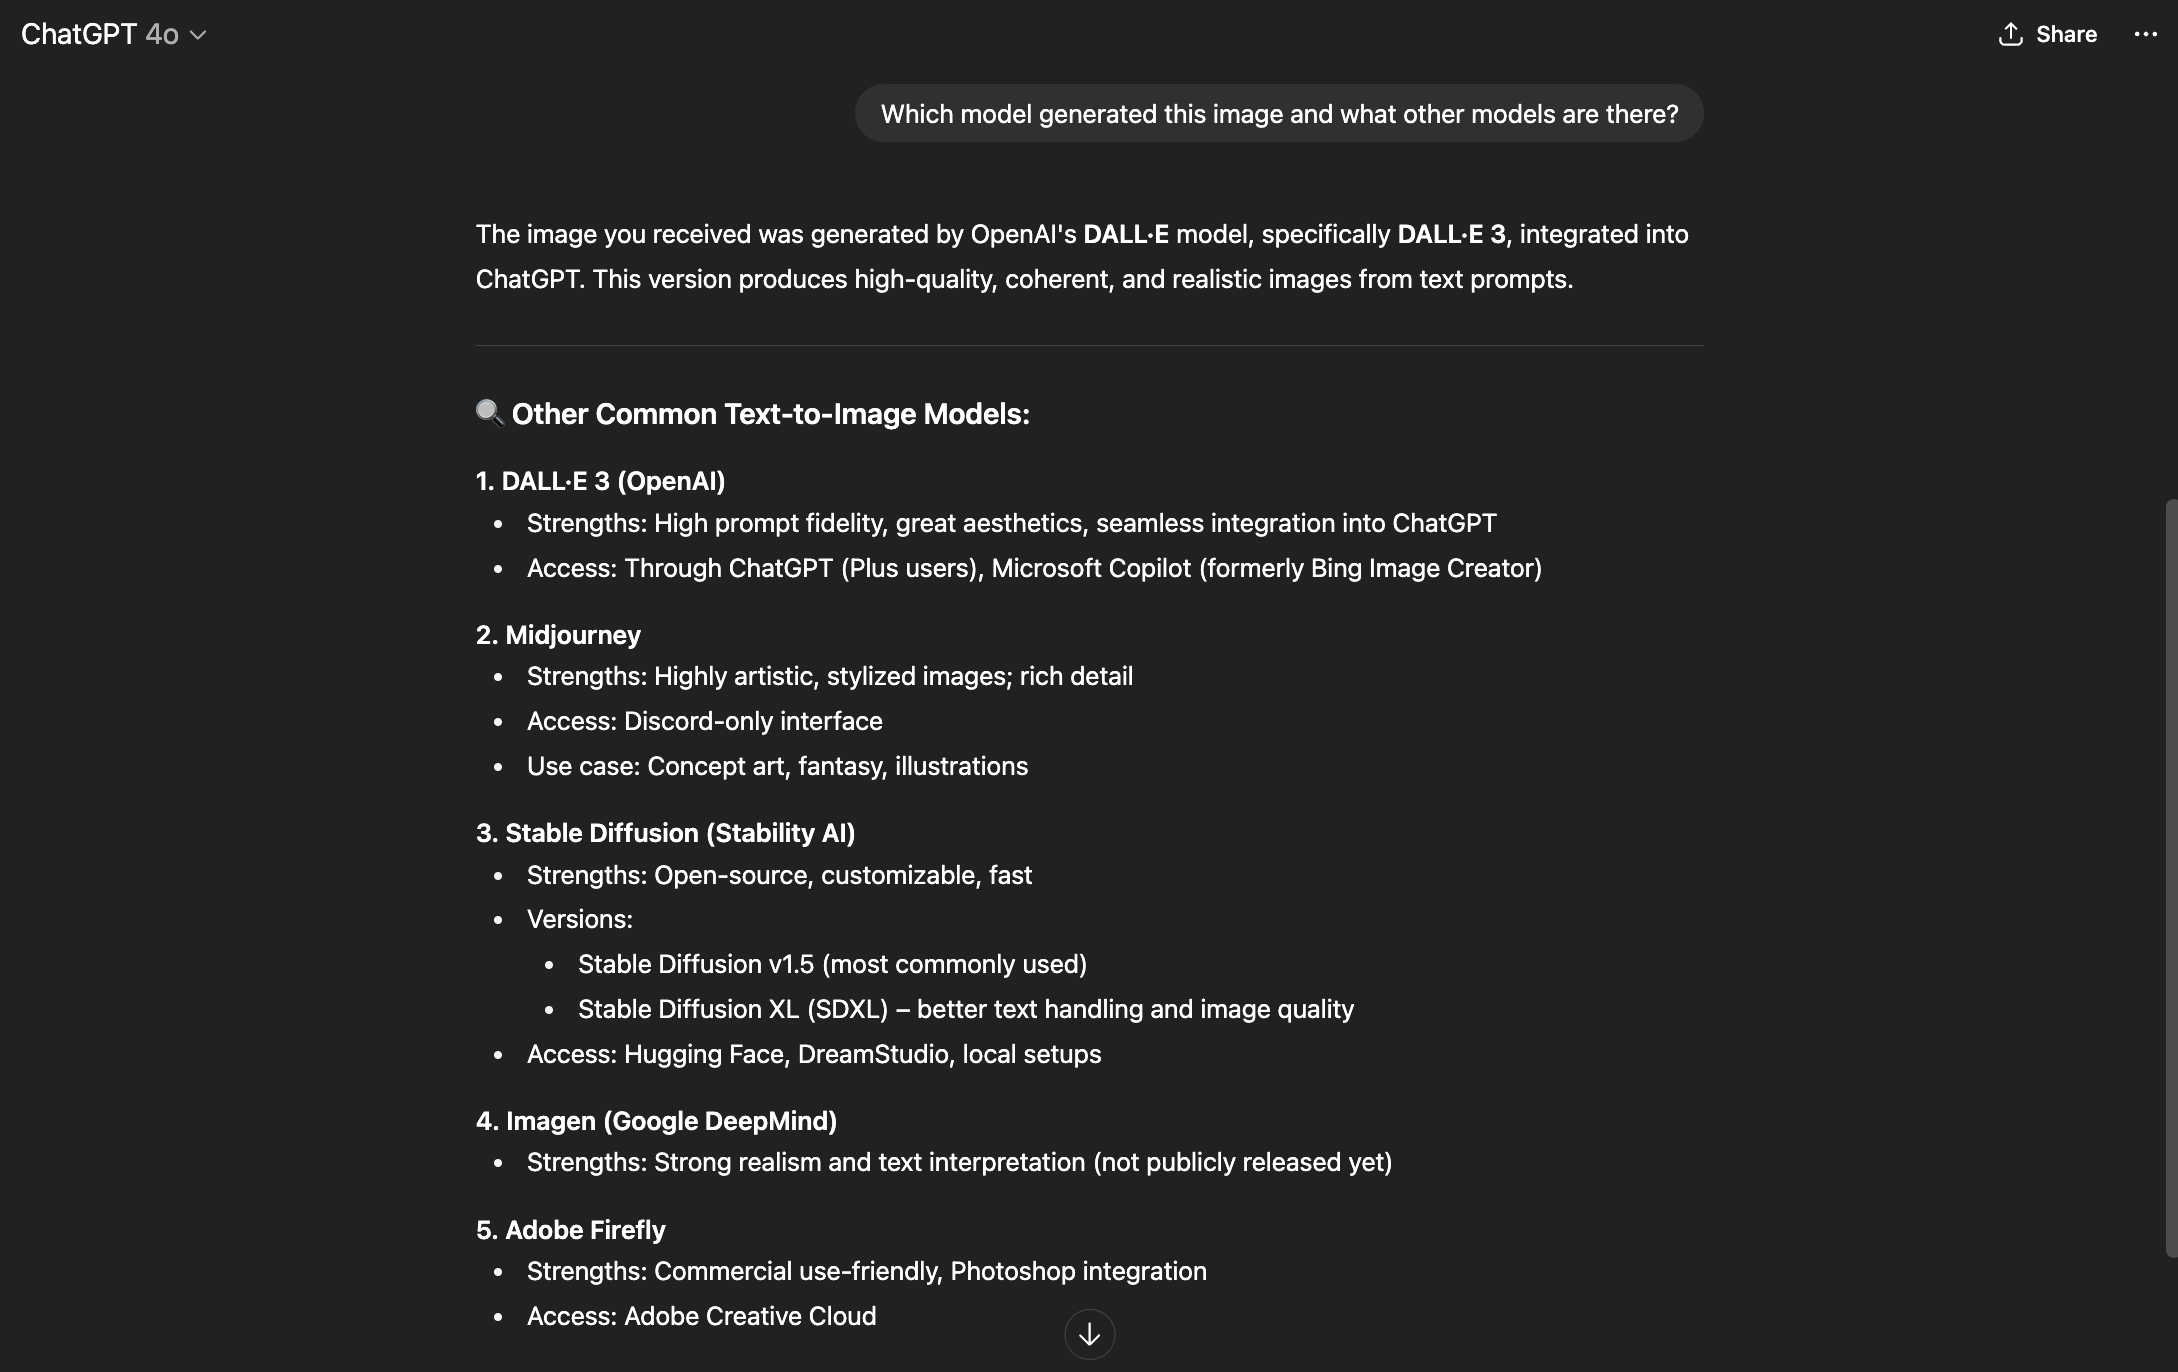


## Part 3: Image-to-text

We just learned how to generate images from text. Now, let's go the opposite direction and generate text from images. We discuss some of the most common use cases of image-to-text below.

#### 1. Summarization (Image Summarization) 📝
- Goal: Generate a concise textual summary of the overall scene or content in an image.
- Example
 - Input: Photo of people dining outdoors at a restaurant.  
 - Output: "A group of friends enjoying a meal at a sidewalk café."
- Common Uses: news/photojournalism, image databases (auto-tagging)

#### 2. Visual Question Answering (VQA) ❓
- Goal: Answer a natural language question based on the visual content of an image.
- Example
 - Image: A man holding a tennis racket  
 - Question: "What sport is being played?"  
 - Answer: "Tennis"
- Common Uses: AI assistants, multimodal chatbots (e.g., GPT-4V)

#### 3. Image-Based Reasoning or Inference 🧠
- Goal: Make logical or commonsense inferences from visual inputs.
- Example
 - Image: An umbrella on wet pavement  
 - Output: "It recently rained."
- Common Uses: story understanding, decision-support systems, multimodal LLMs

#### 4. Keyword/Tag Generation 🏷
- Goal: Extract descriptive keywords or tags from the image.
- Example Output: `["sunset", "mountains", "reflection", "lake"]`
- Common Uses:image search, content categorization

#### 5. OCR + Captioning (Document Understanding) 🧾
- Goal: Read and describe the content of images with embedded text.
- Example Output: "A login page with fields for username and password."
- Common Uses: business workflows, scanned documents, ID verification

#### 6. Multimodal Prompting/Input for Other Tasks 🧰
- Goal: Use image-to-text output as input to another task (e.g., translation, summarization, Q&A).
- Example Workflow:`Image → Caption → Translate to French → Use in chatbot`
- Common Uses: multilingual applications, instruction-following agents


In this part of the recitation, we will focus on the image summarization task.

Like before, we'll start first with the local model approach. We will use the BLIP (Bootstrapped Language Image Pretraining) model from Hugging Face, which is one of the most reliable models for this task.

We first install our required packages and import the dependencies (libraries).

In [1]:
# Install required packages (only need to run once)
!pip install -q transformers timm torch torchvision
!pip install -q accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.5 MB/s eta 0:00:00


In [2]:
# Import dependencies
import torch
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

Next, we load the image locally into this notebook from where we uploaded the image into the Colab files. In this case, the image is saved in the path, `dog_in_mountains.png`

In [ ]:
# Set the path to the image in the Colab files.
image_path = "dog_in_mountains.png"

# Load the image
image = Image.open(image_path).convert('RGB')

Then, we load the BLIP model by loading both its processor and model.

Here, the `processor` is a preprocessing and postprocessing tool. You can think of it as a wrapper that prepares the input for the model and interprets its output. For BLIP and similar vision models, it:
- Preprocesses the image (resizes, normalizes, converts to tensors)
- (If needed) Tokenizes text (for input or generation)
- Decodes model output into human-readable text

The `model` is the neural network itself that is doing the inference. It contains the actual layers, like the encoder and decoder layers. In the case of BLIP and similar vision models it is responsible for encoding visual features and generating language tokens.

In [4]:
# Load BLIP model and processor
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").eval()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The code below performs the actual text generation from the image.

The first block of code uses the processor to preprocess the image into model-ready tensors. This involves resizing and normalizing the image, convering it into a PyTorch tensor (`return_tensors="pt"`), and moving the tensor to the same device (CPU or GPU) as the model using `.to(model.device)`. This is important because the model expects a tensor with the right shape, data type, and device. This line prepares the input correctly.

The second block of code runs the model’s decoder to generate a caption by using the processed image as input (`**inputs`) and limiting the generated caption to 50 tokens (`max_length=50`). Note that this is the actual caption generation step — it outputs a sequence of token IDs representing the predicted text and saves it into the variable `output`.

The final block of code takes the generated token IDs (`output[0]`) and converts them back into human-readable text. The parameter `skip_special_tokens=True` removes special tokens. This effectively transforms the raw model output (token IDs) into a clean caption you can read and understand. This then gets printed out for display in the notebook.

In [5]:
# Prepare input for the model
inputs = blip_processor(images=image, return_tensors="pt").to(model.device)

# Generate a description (summarization of the image)
with torch.no_grad():
    output = blip_model.generate(**inputs, max_length=50)

# Decode and display result
caption = blip_processor.decode(output[0], skip_special_tokens=True)
print("🔍 Summary of the image:", caption)

`cache.key_cache[idx]` is deprecated and will be removed in v4.56.0. Use `cache.layers[idx].keys` instead.
`cache.value_cache[idx]` is deprecated and will be removed in v4.56.0. Use `cache.layers[idx].values` instead.


🔍 Summary of the image: a dog sitting on top of a mountain


There is no easily found free API-based model for , so we will next show how we can generate text from image using the web-based model ChatGPT. Using the same image, we can ask ChatGPT to summarize the image:

We can also ask what model it used to summarize the image and ask about other image-to-text models that are available:



# Part 4: Text-to-text

Last but not least, we will discuss text-to-text tasks. More specifically, text-to-text models take one text input and generate another text output. These tasks are central to natural language processing (NLP) and cover a wide range of applications.

#### 1. Translation 🗣️
- Task: Translate text from one language to another  
- Input: "Translate English to French: The cat is sleeping."  
- Output: "Le chat dort."

#### 2. Summarization 📝
- Task: Generate a concise summary of a longer text  
- Input: "Summarize: The company reported record earnings this quarter..."  
- Output: "The company had record earnings."

#### 3. Sentence Completion ✍️
- Task: Predict or complete the next part of a sentence  
- Input: "She walked into the room and saw"  
- Output: "a group of people waiting to surprise her."

#### 4. Question Answering ❓
- Task: Answer a question based on context or general knowledge  
- Input: "Q: What is the capital of Japan?"  
- Output: "Tokyo"

#### 5. Paraphrasing 🧾
- Task: Rewrite a sentence with different words but the same meaning  
- Input: "Paraphrase: He is very intelligent."  
- Output: "He is highly smart."

#### 6. Grammar Correction 🚨
- Task: Fix grammatical mistakes in a sentence  
- Input: "Fix grammar: She no went to school."  
- Output: "She did not go to school."

#### 7. Text Classification (as text generation) 🎯
- Task: Predict a label or category in text form  
- Input: "Classify sentiment: I love this movie!"  
- Output: "Positive"

#### 8. Dialogue and Chatbots 🔁
- Task: Generate conversational responses  
- Input: "User: What's your name?\nAI:"  
- Output: "I'm your AI assistant. How can I help you?"

#### 9. Instruction Following 💡
- Task: Perform a task based on a natural-language instruction  
- Input: "Write a tweet about climate change."  
- Output: "Climate change is real and urgent. Let's act now. 🌍🔥 #ClimateAction"

#### 10. Text Simplification 🔐
- Task: Rewrite text to make it easier to understand  
- Input: "Simplify: Photosynthesis is the process by which green plants and some other organisms use sunlight to synthesize foods from carbon dioxide and water."  
- Output: "Photosynthesis is how plants make food using sunlight."

For our discussion below, we will focus on sentence completion and summarizaiton.

Let's start with using the first approach, local models. We will use a few models to showcase how their responses differ, including GPT2 and Google's Pegasus.

We first install and import the required libraries.

In [1]:
# Install required libraries
!pip install transformers

In [2]:
# Import libraries
from transformers import BertModel, BertTokenizer, pipeline, set_seed
import torch

Next, we create a text generation pipeline using the GPT-2 model.  `pipeline(...)` is a high-level Hugging Face function that loads models and tokenizers behind the scenes. The argument `"text-generation"` specifies the task — here, we want to generate text continuations. The argument `model="gpt2"` tells the pipeline to use OpenAI’s GPT-2, a pretrained language model. This code block therefore results in the `generator` object, which can autocomplete or continue a given prompt.

In [ ]:
gpt2_generator = pipeline("text-generation", model="gpt2")


The below code block actually generates the text from GPT2. The first code block first defines the text prompt we want to give GPT2, in this case a sentence about the MIT Sloan School of Management that we want the model to finish.

The next line then calls the GPT-2 generator with the provided prompt and generation settings. The following parameters are used:
- `text_prompt` the starting input to complete.
- `max_length=30` limits the total number of tokens in the generated output (including the prompt).
- `num_return_sequences=1` returns only one generated result.

The final line of code simply prints the generated result from GPT2.

In [3]:

text_prompt = """The mission of the MIT Sloan School of Management is
to develop principled, innovative leaders who """

result = gpt2_generator(text_prompt, max_length=30, num_return_sequences=1)

print(result[0]["generated_text"])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The mission of the MIT Sloan School of Management is
to develop principled, innovative leaders who  can make the world a better place.
The MIT Sloan School of Management is an international research center dedicated to the design, implementation, and management of software and information systems.
The mission of the MIT Sloan School of Management is to develop principled, innovative leaders who  can make the world a better place. The MIT Sloan School of Management is supported as an independent research and education organization by the National Science Foundation and the Massachusetts Institute of Technology.
The mission of the MIT Sloan School of Management is to develop principled, innovative leaders who  can make the world a better place. The MIT Sloan School of Management is supported as an independent research and education organization by the National Science Foundation and the Massachusetts Institute of Technology.


We can also perform a summarization task in this way. First, we create another pipeline object but this time with the argument `"summarization"` to tell the pipeline that we want to perform the summarization task. Note that since no model was specified in this pipeline, it defaults to the model `sshleifer/distilbart-cnn-12-6`, which is a small, simple model.

In [ ]:
## using pipeline and task name to load a summarizer from a pre-trained model
default_summarizer = pipeline("summarization")

Next, let's define the text that we want to summarize. We will store this text in the variable `article`.

In [ ]:
article = """The only thing crazier than a guy in snowbound Massachusetts
boxing up the powdery white stuff
and offering it for sale online? People are actually buying it.
For $89, self-styled entrepreneur Kyle Waring will ship you 6 pounds
of Boston-area snow in an insulated Styrofoam box –
enough for 10 to 15 snowballs, he says.
But not if you live in New England or surrounding states.
His website and social media accounts claim to have filled more than 133 orders
for snow – more than 30 on Tuesday alone, his busiest day yet.
With more than 45 total inches, Boston has set a record this winter
for the snowiest month in its history. Most residents see the huge piles
of snow choking their yards and sidewalks as a nuisance, but Waring saw an
opportunity. According to Boston.com, it all started a few weeks ago,
when Waring and his wife were shoveling deep snow from their yard in
Manchester-by-the-Sea, a coastal suburb north of Boston. He joked about
shipping the stuff to friends and family in warmer states, and an
idea was born. His business slogan: “Our nightmare is your dream!”
At first, ShipSnowYo sold snow packed into empty 16.9-ounce water
bottles for $19.99, but the snow usually melted before it
reached its destination.
"""

Similar to before, we generate and print the summarization from the model output, this time allowing the model to return a response of at most 50 tokens.

In [4]:
result = default_summarizer(article, max_length=50, min_length=30, num_return_sequences=1) #generates the summarization

print(result[0]["summary_text"])

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


' For $89, you can buy 6 pounds of snow in an insulated Styrofoam box for $19.99 . More than'

This summarization wasn't very good, was it? Let's try a different model! This time, let's try using Google's Pegasus model for summarization. You can also try changing it to other models. We will do the same steps as before.

In [5]:
pegasus_summarizer = pipeline("summarization", model = "google/pegasus-xsum") # change the model to your favorite one

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/259 [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

Device set to use cuda:0


"It's the stuff of dreams for many: snow that can be shipped to your front door for as little as $89 (or more if"

In [6]:

result = pegasus_summarizer(article, max_length=50, min_length=30, num_return_sequences=4) #generates the summarization
result[0]["summary_text"]

"It's the stuff of dreams for many: snow that can be shipped to your front door for as little as $89 (or more if you live in colder states)."

Now, isn't that a better response? It's also got a lot of personality in the response.

It is interesting to see how different models produce different results. When thinking about your tasks, it is therefore important to think about which model you want to use.

Next, let's use an API-based model to perform text summarization on our snow article. We first need to import the necessary libraries. We then set our API token like our previous example of using an API-based model with text-to-image tasks, and we also define the endpoint (like a URL) for the summarization model. We will use Facebook's Bart model for this.

Note that the headers are special lines or sections that indicate structure, context, or metadata. These are useful for such API-based models and help with requests/responses.

In [7]:
import requests
from getpass import getpass

In [9]:
# 🔐 Hugging Face API token
API_TOKEN = getpass("Enter your Hugging Face API token: ")

# Summarization model endpoint (URL)
API_URL = "https://api-inference.huggingface.co/models/facebook/bart-large-cnn"
headers = {"Authorization": f"Bearer {API_TOKEN}"}

Enter your Hugging Face API token: ··········


The below code then makes the actual request to the API-based model, using API endpoint we defined, the headers we defined, and the previous variable `article` as input (recall this stores the snow-related text). Then, we extract the actual text from the API's response and print it.

In [10]:

# Send request
response = requests.post(API_URL, headers=headers, json={"inputs": article})

summary = response.json()[0]["summary_text"]
print("📝 Summary:\n", summary)


📝 Summary:
 For $89, you can buy 6 pounds of Boston-area snow in an insulated Styrofoam box. With more than 45 inches of snow, Boston has set a record for the snowiest month in its history. The website and social media accounts claim to have filled more than 133 orders Tuesday.


Seems like this is also a pretty good summary! It is more standard answer compared to Google's Pegasus model.

Finally, we will discuss text-to-text using the web-based model ChatGPT. Essentially anything you do with ChatGPT is text-to-text, as it is a conversation-based application. Anything related to images, videos, or audio, would not be included in the text-to-text tasks, however.

Let's see what ChatGPT does with our snow-related text:
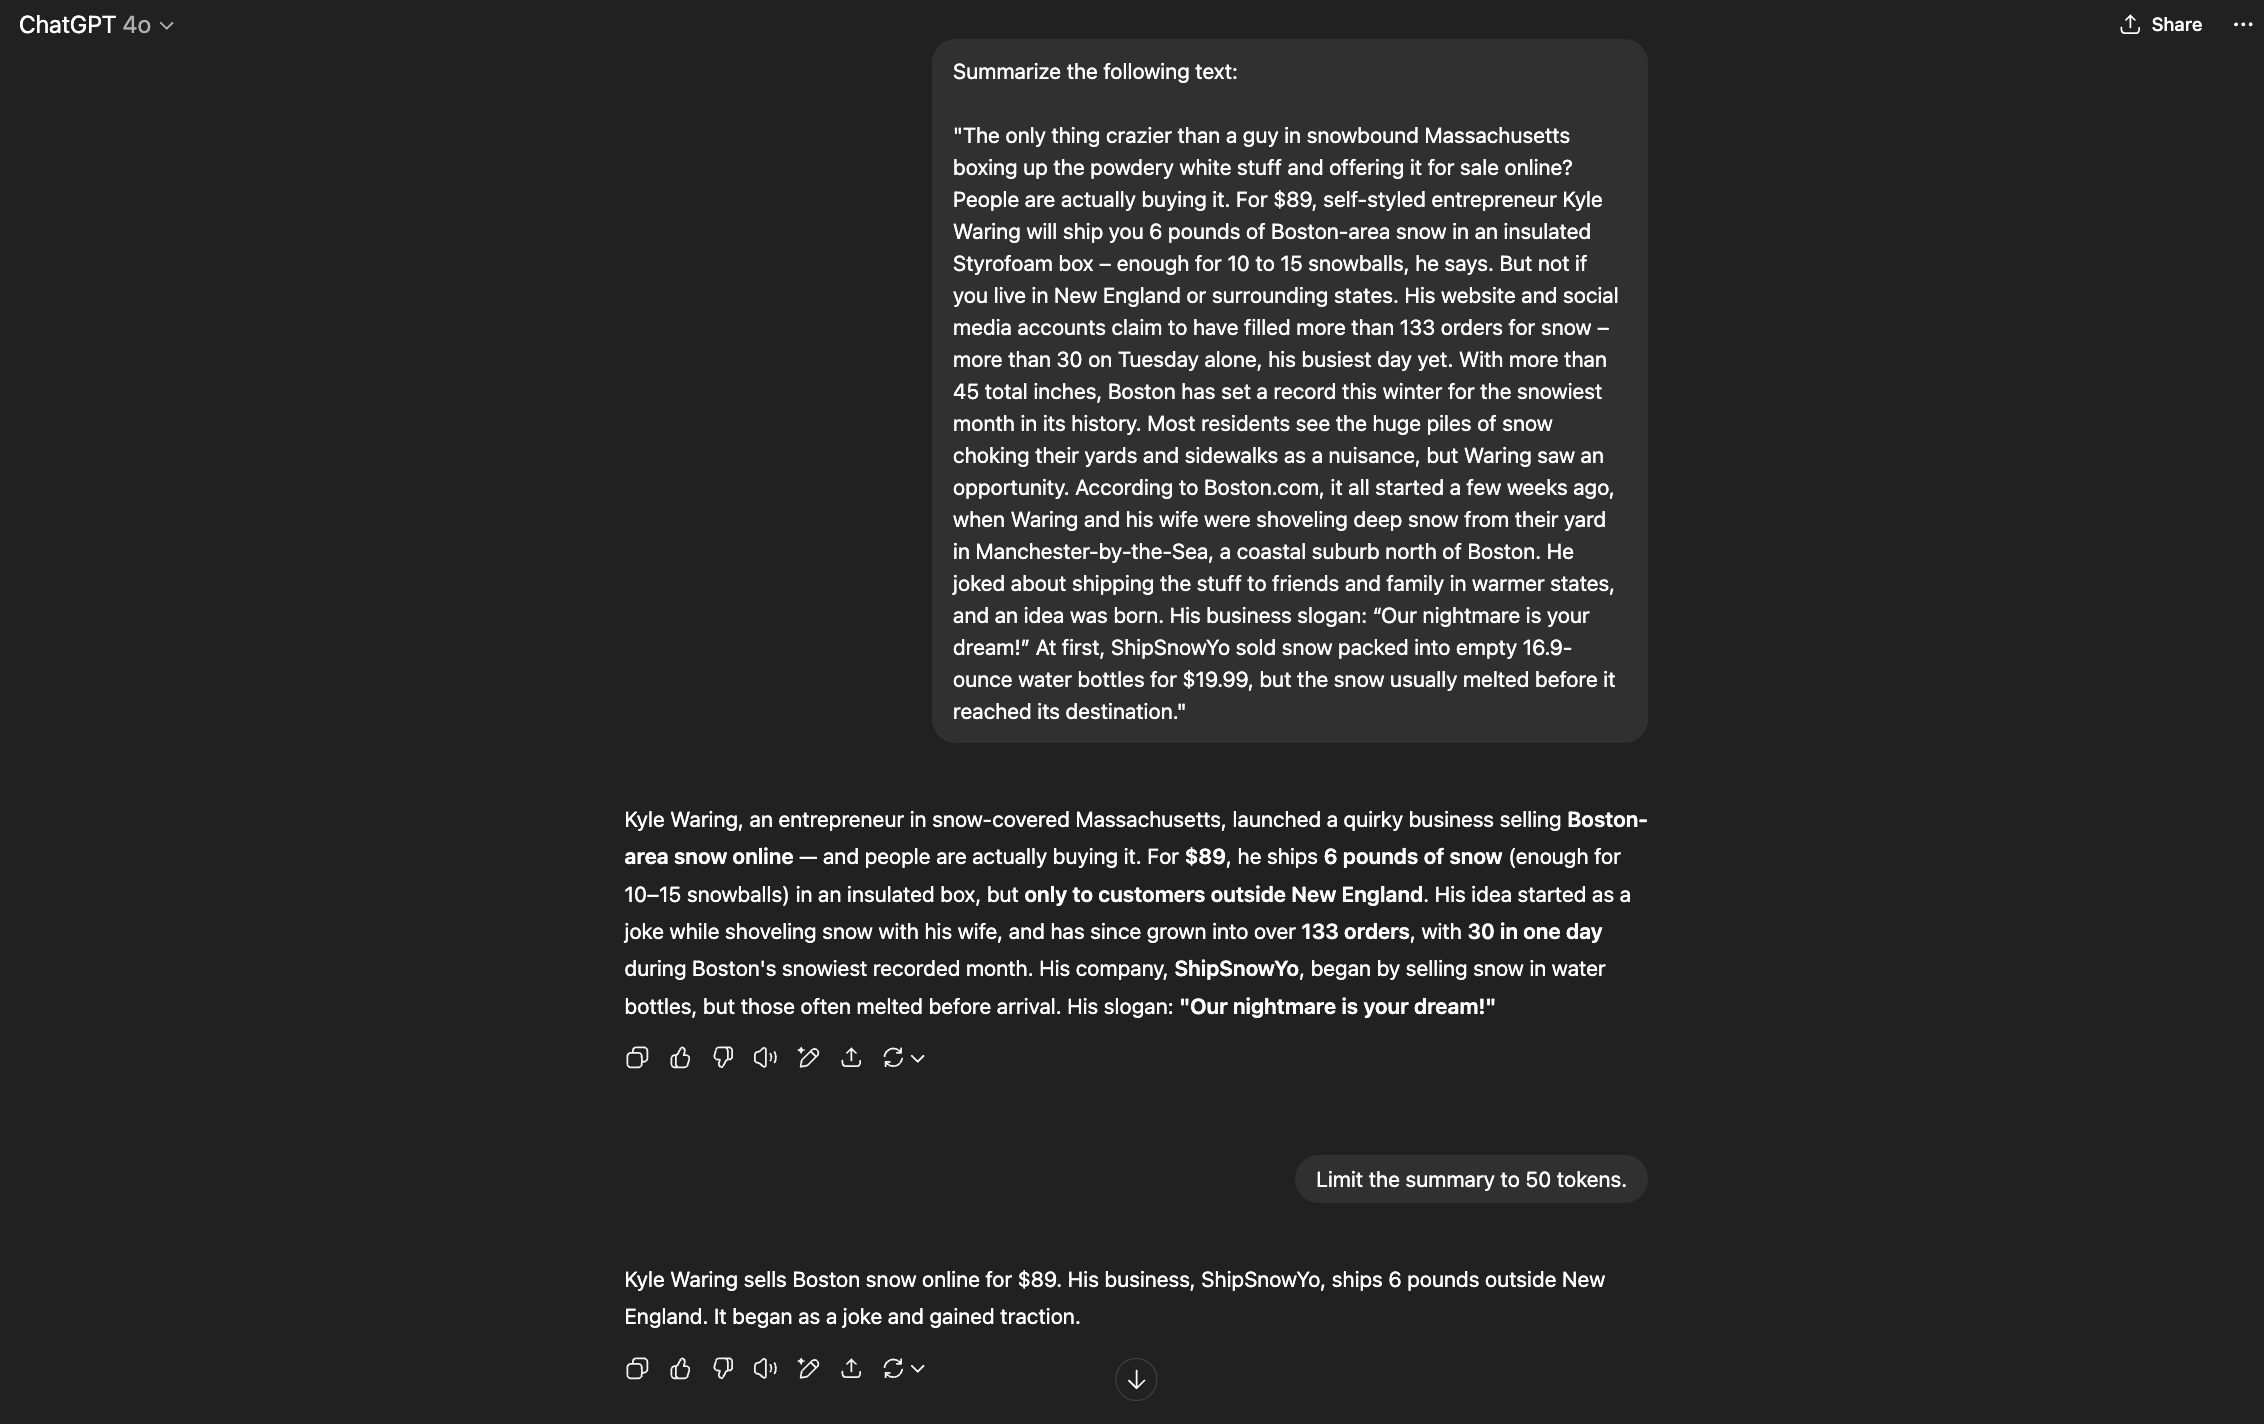

# Congratulations! This concludes Recitation 1 of Module 12.

# Glossary of terms

- **Accelerate (Hugging Face library).** [Accelerate](https://huggingface.co/docs/accelerate/en/index) is a lightweight library by Hugging Face designed to simplify multi-GPU, mixed-precision, and distributed training of PyTorch models. It abstracts away the boilerplate typically required for hardware-aware training, allowing users to write code once and run it seamlessly on CPUs, a single GPU, or across multiple GPUs. Accelerate is especially useful for fine-tuning large language models, prototyping quickly, and scaling up to production without changing core training logic. It integrates smoothly with other Hugging Face tools.

- **API.** An API (Application Programming Interface) is a set of rules that allows different software systems to communicate with each other. More simply, it is a way for one program to send requests to another program or service and get responses back. It lets you use tools like ChatGPT or a weather service in your own app without needing to know how they work internally. APIs are commonly used to integrate external tools, databases, or models into apps or workflows.

- **Byte.** A byte is the raw binary representation of data — the smallest unit of storage used to encode information like text, images, or audio in digital systems. A byte typically consists of 8 bits and can represent values from 0 to 255. In Python, bytes objects are used to handle binary data such as files, images, or network transmissions.


- **ChatGPT (OpenAI).** [ChatGPT](https://chat.openai.com) is a conversational AI chatbot developed by OpenAI, powered by the GPT family of language models. It allows users to interact naturally through text and supports a wide range of tasks including writing, coding, research assistance, and image analysis (in GPT-4o). It offers both free and paid tiers, with premium users gaining access to more powerful models and features like file upload, memory, and multimodal capabilities.

- **Claude.ai (Anthropic).** [Claude.ai](https://claude.ai/) is the web-based interface for Anthropic’s Claude models, designed to prioritize helpfulness, honesty, and harmlessness. Users can interact with Claude for writing, analysis, summarization, and reasoning tasks.

- **Cloud.** The cloud refers to remote servers that store data and run software over the internet instead of on your local computer. It lets you access files, apps, and computing power from anywhere, without needing to manage physical hardware.

- **CPU.** A CPU is the general-purpose processor found in nearly all computers. It excels at handling sequential tasks and is optimized for flexibility, logic operations, and low-latency execution. CPUs are ideal for running operating systems, managing workflows, and executing traditional software applications. While typically having fewer cores than GPUs, each CPU core is powerful and well-suited for tasks that require complex decision-making and branching logic.

- **Datasets (Hugging Face library).** The [datasets library](https://huggingface.co/docs/datasets/en/index) by Hugging Face is a lightweight and efficient toolkit for accessing, preprocessing, and sharing datasets in machine learning workflows. It provides access to thousands of ready-to-use datasets for NLP, computer vision, audio, and more — all with standardized formats and metadata. The library supports streaming, lazy loading, and memory-efficient processing, making it ideal for working with large datasets even on limited hardware. Integration with PyTorch and TensorFlow is seamless.

- **Decoder Layer.** A decoder layer generates output tokens one by one, using masked self-attention (to consider only past tokens) and cross-attention (to reference encoder outputs). It’s used in tasks like translation, captioning, and summarization.

- **Encoder Layer.** An encoder layer processes input (like words or image patches) by applying self-attention and feedforward transformations to generate rich, contextual embeddings. It helps the model understand relationships between elements in the input.

- **Gemini (Google).** [Gemini](https://gemini.google.com/), developed by [Google DeepMind](https://deepmind.google/), is a family of multimodal language models integrated into Google's ecosystem. It offers features like coding help, document generation, image understanding, and integration with Gmail, Docs, and other Google services. Gemini combines text, image, and code reasoning in a conversational interface designed for both casual and professional use.

- **GPT (OpenAI).** GPT (Generative Pretrained Transformer) is a family of large language models developed by OpenAI. These models are based on the Transformer architecture and are trained on massive datasets using unsupervised learning to predict the next word in a sequence. After pretraining, they can be fine-tuned or prompted for a wide range of natural language tasks, such as text generation, summarization, translation, and question answering. The most advanced versions — such as GPT-3.5, GPT-4, and GPT-4o — power OpenAI’s tools like ChatGPT and the OpenAI API, enabling both conversational AI and general-purpose reasoning across text, code, and even image inputs (in multimodal models).

- **GPU.** A GPU is a specialized processor designed for parallel computation, originally developed for rendering graphics. Modern GPUs are widely used in deep learning because they can perform thousands of simple operations simultaneously, making them highly efficient for matrix multiplications and tensor operations. This parallelism allows for significant acceleration in training and inference of machine learning models, especially large-scale neural networks.

- **Hugging Face.** [Hugging Face](https://huggingface.co/) is an open-source AI company and platform known for democratizing access to state-of-the-art machine learning models. It hosts the Hugging Face Hub, a central repository for thousands of pretrained models, datasets, and training scripts covering tasks like text generation, translation, image classification, audio processing, and more. Hugging Face also develops powerful libraries such as transformers, datasets, and accelerate, making it easy for researchers and developers to build, fine-tune, and deploy models with minimal setup. The platform fosters a strong community of contributors and has become a cornerstone of modern AI development.

- **Inference.** Inference is the process of using a trained machine learning model to make predictions or generate outputs based on new, unseen input data/ In the context of generative AI, inference means running the model (like GPT or Stable Diffusion) to generate a response, image, or other result — without training or updating the model. For example, entering a prompt into ChatGPT and getting a reply is an inference step. In other words, t's the deployment phase of a model — when you're putting it to work, not teaching it.

- **PyTorch.** [PyTorch](https://pytorch.org/) is an open-source deep learning framework developed by [Meta AI](https://ai.meta.com/). It provides a flexible, dynamic computational graph that makes it easy to build and debug neural networks using standard Python code. PyTorch is widely adopted in both research and industry for its intuitive syntax, strong GPU acceleration, and native support for automatic differentiation

- **Remote server.** A remote server is a computer or group of computers located elsewhere (usually in a data center or the cloud) that hosts services or runs programs on behalf of users. When you use an API or web application, your request is sent to a remote server, which processes it and returns the result.

- **Request.** A query is a request for information sent to a system, such as a database, search engine, or AI model. It usually includes specific input or instructions, and the system responds with relevant data or results.

- **Tensor.** A tensor is a multi-dimensional array used to store data in machine learning, such as scalars (0D), vectors (1D), matrices (2D), or higher-dimensional structures. It's the fundamental data type in deep learning frameworks like PyTorch and TensorFlow.

- **Tensorflow.** [TensorFlow](https://www.tensorflow.org/) is an open-source deep learning framework developed by Google. It offers a robust and scalable ecosystem for building and deploying machine learning models across a wide range of platforms, including servers, edge devices, and mobile apps.

- **Token.** A token is a small unit of text — like a word, subword, or character — that a model processes. Models use token sequences as input and generate token sequences as output.

- **Transformers (Hugging Face library).** The [Transformers library](https://huggingface.co/docs/transformers/en/index) by Hugging Face is a popular open-source toolkit for working with state-of-the-art machine learning models, particularly large language models (LLMs). It provides a simple interface for loading pretrained models for tasks like text generation, classification, translation, summarization, and more. Transformers supports models from a wide range of sources and allows you to run them locally or via the Hugging Face Hub. It is widely used in research and production for its flexibility, community support, and ease of fine-tuning.